## 0. Kaggle Download & Dataset Setup

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'PASTE_YOUR_USERNAME_HERE'
os.environ['KAGGLE_KEY'] = 'PASTE_YOUR_KEY_HERE'

!pip install -q kaggle
!kaggle datasets download -d ahmedxc4/skin-ds
!unzip -qo skin-ds.zip -d /content/skin_ds
!ls /content/skin_ds

Dataset URL: https://www.kaggle.com/datasets/ahmedxc4/skin-ds
License(s): CC0-1.0
skin-ds.zip: Skipping, found more recently modified local copy (use --force to force download)
README.md  test  train	val


In [ ]:
!ls /content/skin_ds/train

'Actinic keratoses'		  Dermatofibroma      Melanoma
'Basal cell carcinoma'		  Healthy	      Monkeypox
'Benign keratosis-like lesions'   HFMD		     'Squamous cell carcinoma'
 Chickenpox			  Measles	     'Vascular lesions'
 Cowpox				 'Melanocytic nevi'


## 1. Environment Setup & Data Loading

In [ ]:
import os, time, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

DATASET_ROOT = '/content/skin_ds'
TRAIN_DIR = f'{DATASET_ROOT}/train'
VAL_DIR   = f'{DATASET_ROOT}/val'
TEST_DIR  = f'{DATASET_ROOT}/test'

PROJECT_ROOT = '/content/drive/MyDrive/Skin_Lesion_Project'
RESULTS_DIR  = f'{PROJECT_ROOT}/results'
FIG_DIR      = f'{RESULTS_DIR}/figures'
CKPT_DIR     = f'{RESULTS_DIR}/checkpoints'

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

assert os.path.exists('/content/drive/MyDrive'), \
    "Google Drive did not mount correctly — do not proceed with training yet."
print("Google Drive confirmed connected.")

for d in (RESULTS_DIR, FIG_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

def set_seeds(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hardware_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f"Using device: {device} ({hardware_name})")

for d, label in [(TRAIN_DIR, 'train'), (VAL_DIR, 'val'), (TEST_DIR, 'test')]:
    if not os.path.exists(d):
        raise FileNotFoundError(
            f"Expected {label} folder at {d} but it doesn't exist. "
            "Did you run the Kaggle download + unzip cell first?"
        )

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), normalize
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), normalize
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

assert train_ds.class_to_idx == val_ds.class_to_idx == test_ds.class_to_idx, \
    "Class folders differ between train/val/test — check for missing class folders."

CLASSES = train_ds.classes
IDX_TO_CLASS = {i: c for c, i in train_ds.class_to_idx.items()}
NUM_CLASSES = len(CLASSES)
print(f"{len(train_ds)} train / {len(val_ds)} val / {len(test_ds)} test images, "
      f"{NUM_CLASSES} classes: {CLASSES}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

train_targets = [label for _, label in train_ds.samples]
counts = np.bincount(train_targets, minlength=NUM_CLASSES)
weights = 1.0 / torch.tensor(counts, dtype=torch.float32).clamp(min=1)
weights = (weights / weights.sum()) * len(weights)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
print("Class counts (train):", dict(zip(CLASSES, counts.tolist())))

Mounted at /content/drive
Google Drive confirmed connected.
Using device: cuda (Tesla T4)
29322 train / 3660 val / 3674 test images, 14 classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Chickenpox', 'Cowpox', 'Dermatofibroma', 'HFMD', 'Healthy', 'Measles', 'Melanocytic nevi', 'Melanoma', 'Monkeypox', 'Squamous cell carcinoma', 'Vascular lesions']
Class counts (train): {'Actinic keratoses': 693, 'Basal cell carcinoma': 2658, 'Benign keratosis-like lesions': 2099, 'Chickenpox': 900, 'Cowpox': 792, 'Dermatofibroma': 191, 'HFMD': 1932, 'Healthy': 1368, 'Measles': 660, 'Melanocytic nevi': 10300, 'Melanoma': 3617, 'Monkeypox': 3408, 'Squamous cell carcinoma': 502, 'Vascular lesions': 202}


## 2. Training Engine (shared by all approaches)

In [ ]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, optimizer, name, epochs, scheduler=None):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'lr': []}
    ckpt_path = os.path.join(CKPT_DIR, f'{name}_best.pth')
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f"{name} epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_ds)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = torch.argmax(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_loss /= len(val_ds)
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        if scheduler is not None:
            scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)
        print(f"  -> train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
              f"val_macroF1={val_f1:.4f} lr={current_lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'class_to_idx': train_ds.class_to_idx,
            }, ckpt_path)

    elapsed = time.time() - start_time
    n_params = count_trainable_params(model)
    print(f"{name}: {n_params:,} trainable params, {elapsed/60:.1f} min on {hardware_name}")
    return history, n_params, elapsed

## 3. Approach 1 — Custom CNN (trained from scratch)

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.encoder(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

print("\n=== Approach 1: Custom CNN (from scratch) ===")
model_1 = CustomCNN(NUM_CLASSES).to(device)
opt_1 = optim.Adam(model_1.parameters(), lr=1e-3, weight_decay=1e-4)
sched_1 = optim.lr_scheduler.ReduceLROnPlateau(opt_1, mode='min', factor=0.5, patience=3)
hist_1, params_1, time_1 = train_model(model_1, opt_1, "cnn_scratch", epochs=25, scheduler=sched_1)


=== Approach 1: Custom CNN (from scratch) ===


cnn_scratch epoch 1/25: 100%|██████████| 917/917 [06:02<00:00,  2.53it/s]


  -> train_loss=2.3840 val_loss=2.2386 val_macroF1=0.1458 lr=1.00e-03


cnn_scratch epoch 2/25: 100%|██████████| 917/917 [05:47<00:00,  2.64it/s]


  -> train_loss=2.2388 val_loss=2.0089 val_macroF1=0.2262 lr=1.00e-03


...

  -> train_loss=1.2057 val_loss=1.1064 val_macroF1=0.5297 lr=5.00e-04


cnn_scratch epoch 24/25: 100%|██████████| 917/917 [05:38<00:00,  2.71it/s]


  -> train_loss=1.1949 val_loss=1.1055 val_macroF1=0.5226 lr=5.00e-04


cnn_scratch epoch 25/25: 100%|██████████| 917/917 [05:39<00:00,  2.70it/s]


  -> train_loss=1.1620 val_loss=1.1460 val_macroF1=0.5256 lr=5.00e-04
cnn_scratch: 392,974 trainable params, 158.3 min on Tesla T4


## 4. Approach 2 — ResNet-18 (frozen backbone / linear probe)

In [ ]:
print("\n=== Approach 2: ResNet-18 frozen backbone (linear probe) ===")
model_2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
for param in model_2.parameters():
    param.requires_grad = False
model_2.fc = nn.Linear(model_2.fc.in_features, NUM_CLASSES).to(device)
opt_2 = optim.Adam(model_2.fc.parameters(), lr=1e-3, weight_decay=1e-4)
sched_2 = optim.lr_scheduler.ReduceLROnPlateau(opt_2, mode='min', factor=0.5, patience=2)
hist_2, params_2, time_2 = train_model(model_2, opt_2, "resnet_frozen", epochs=15, scheduler=sched_2)


=== Approach 2: ResNet-18 frozen backbone (linear probe) ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]
resnet_frozen epoch 1/15: 100%|██████████| 917/917 [06:05<00:00,  2.51it/s]


  -> train_loss=1.5969 val_loss=1.1863 val_macroF1=0.4714 lr=1.00e-03


resnet_frozen epoch 2/15: 100%|██████████| 917/917 [05:51<00:00,  2.61it/s]


  -> train_loss=1.2944 val_loss=1.3933 val_macroF1=0.4447 lr=1.00e-03


...

  -> train_loss=1.0306 val_loss=1.0357 val_macroF1=0.5369 lr=1.25e-04


resnet_frozen epoch 14/15: 100%|██████████| 917/917 [05:55<00:00,  2.58it/s]


  -> train_loss=1.0258 val_loss=1.1197 val_macroF1=0.5211 lr=1.25e-04


resnet_frozen epoch 15/15: 100%|██████████| 917/917 [06:04<00:00,  2.52it/s]


  -> train_loss=1.0336 val_loss=1.1299 val_macroF1=0.5190 lr=1.25e-04
resnet_frozen: 7,182 trainable params, 98.0 min on Tesla T4


In [ ]:
!ls -la /content/drive/MyDrive/Skin_Lesion_Project/results/checkpoints/

total 45031
drwx------ 2 root root     4096 Oct  1 10:23 .
drwx------ 4 root root     4096 Oct  1 08:57 ..
-rw------- 1 root root  1226385 Sep 25 05:22 cnn_scratch_best.pth
-rw------- 1 root root 44876097 Oct  1 10:23 resnet_frozen_best.pth


## 5. Approach 3 — ResNet-18 (fully fine-tuned)

In [ ]:
print("\n=== Approach 3: ResNet-18 fully fine-tuned ===")
model_3 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
model_3.fc = nn.Linear(model_3.fc.in_features, NUM_CLASSES).to(device)
for param in model_3.parameters():
    param.requires_grad = True
opt_3 = optim.Adam(model_3.parameters(), lr=1e-4, weight_decay=1e-4)
sched_3 = optim.lr_scheduler.ReduceLROnPlateau(opt_3, mode='min', factor=0.5, patience=2)
hist_3, params_3, time_3 = train_model(model_3, opt_3, "resnet_finetuned", epochs=15, scheduler=sched_3)


=== Approach 3: ResNet-18 fully fine-tuned ===


resnet_finetuned epoch 1/15: 100%|██████████| 917/917 [06:20<00:00,  2.41it/s]


  -> train_loss=1.0899 val_loss=0.8856 val_macroF1=0.6136 lr=1.00e-04


resnet_finetuned epoch 2/15: 100%|██████████| 917/917 [06:11<00:00,  2.47it/s]


  -> train_loss=0.7790 val_loss=0.7688 val_macroF1=0.6676 lr=1.00e-04


...

  -> train_loss=0.2673 val_loss=0.4519 val_macroF1=0.8328 lr=5.00e-05


resnet_finetuned epoch 14/15: 100%|██████████| 917/917 [05:59<00:00,  2.55it/s]


  -> train_loss=0.2323 val_loss=0.4392 val_macroF1=0.8383 lr=5.00e-05


resnet_finetuned epoch 15/15: 100%|██████████| 917/917 [05:56<00:00,  2.57it/s]


  -> train_loss=0.2115 val_loss=0.4775 val_macroF1=0.8337 lr=5.00e-05
resnet_finetuned: 11,183,694 trainable params, 99.9 min on Tesla T4


In [ ]:
!ls -la /content/drive/MyDrive/Skin_Lesion_Project/results/checkpoints/

total 176224
drwx------ 2 root root      4096 Oct  1 12:14 .
drwx------ 4 root root      4096 Oct  1 08:57 ..
-rw------- 1 root root   1226385 Sep 25 05:22 cnn_scratch_best.pth
-rw------- 1 root root 134341763 Oct  1 12:14 resnet_finetuned_best.pth
-rw------- 1 root root  44876097 Oct  1 10:23 resnet_frozen_best.pth


## 6. Hyperparameter Tuning Sweep

In [ ]:
print("\n=== Hyperparameter tuning sweep on Approach 3 (ResNet-18 fine-tuned) ===")
tuning_results = []

lr, wd = 1e-4, 1e-4
set_seeds()
m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES).to(device)
o = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
h, _, _ = train_model(m, o, f"tune_lr{lr}_wd{wd}", epochs=3)
tuning_results.append({'lr': lr, 'weight_decay': wd,
                        'final_val_loss': h['val_loss'][-1],
                        'final_val_f1': h['val_f1'][-1]})
print(f"Config 1 done: lr={lr}, wd={wd} -> val_f1={h['val_f1'][-1]:.4f}")


=== Hyperparameter tuning sweep on Approach 3 (ResNet-18 fine-tuned) ===


tune_lr0.0001_wd0.0001 epoch 1/3: 100%|██████████| 917/917 [05:52<00:00,  2.60it/s]


  -> train_loss=1.0865 val_loss=0.9040 val_macroF1=0.6183 lr=1.00e-04


tune_lr0.0001_wd0.0001 epoch 2/3: 100%|██████████| 917/917 [05:55<00:00,  2.58it/s]


  -> train_loss=0.7657 val_loss=0.7801 val_macroF1=0.6562 lr=1.00e-04


tune_lr0.0001_wd0.0001 epoch 3/3: 100%|██████████| 917/917 [05:59<00:00,  2.55it/s]


  -> train_loss=0.6579 val_loss=0.6881 val_macroF1=0.7222 lr=1.00e-04
tune_lr0.0001_wd0.0001: 11,183,694 trainable params, 19.5 min on Tesla T4
Config 1 done: lr=0.0001, wd=0.0001 -> val_f1=0.7222


In [ ]:
lr, wd = 1e-5, 1e-4
set_seeds()
m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES).to(device)
o = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
h, _, _ = train_model(m, o, f"tune_lr{lr}_wd{wd}", epochs=3)
tuning_results.append({'lr': lr, 'weight_decay': wd,
                        'final_val_loss': h['val_loss'][-1],
                        'final_val_f1': h['val_f1'][-1]})
print(f"Config 2 done: lr={lr}, wd={wd} -> val_f1={h['val_f1'][-1]:.4f}")

tune_lr1e-05_wd0.0001 epoch 1/3: 100%|██████████| 917/917 [05:56<00:00,  2.57it/s]


  -> train_loss=1.6104 val_loss=1.1971 val_macroF1=0.5339 lr=1.00e-05


tune_lr1e-05_wd0.0001 epoch 2/3: 100%|██████████| 917/917 [05:59<00:00,  2.55it/s]


  -> train_loss=1.0109 val_loss=0.9623 val_macroF1=0.5993 lr=1.00e-05


tune_lr1e-05_wd0.0001 epoch 3/3: 100%|██████████| 917/917 [05:58<00:00,  2.56it/s]


  -> train_loss=0.8572 val_loss=0.8529 val_macroF1=0.6502 lr=1.00e-05
tune_lr1e-05_wd0.0001: 11,183,694 trainable params, 19.6 min on Tesla T4
Config 2 done: lr=1e-05, wd=0.0001 -> val_f1=0.6502


In [ ]:
lr, wd = 1e-4, 0.0
set_seeds()
m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES).to(device)
o = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
h, _, _ = train_model(m, o, f"tune_lr{lr}_wd{wd}", epochs=3)
tuning_results.append({'lr': lr, 'weight_decay': wd,
                        'final_val_loss': h['val_loss'][-1],
                        'final_val_f1': h['val_f1'][-1]})
print(f"Config 3 done: lr={lr}, wd={wd} -> val_f1={h['val_f1'][-1]:.4f}")

tune_lr0.0001_wd0.0 epoch 1/3: 100%|██████████| 917/917 [06:42<00:00,  2.28it/s]


  -> train_loss=1.0914 val_loss=0.8751 val_macroF1=0.6448 lr=1.00e-04


tune_lr0.0001_wd0.0 epoch 2/3: 100%|██████████| 917/917 [05:59<00:00,  2.55it/s]


  -> train_loss=0.7667 val_loss=0.7508 val_macroF1=0.6623 lr=1.00e-04


tune_lr0.0001_wd0.0 epoch 3/3: 100%|██████████| 917/917 [06:01<00:00,  2.54it/s]


  -> train_loss=0.6632 val_loss=0.6817 val_macroF1=0.6972 lr=1.00e-04
tune_lr0.0001_wd0.0: 11,183,694 trainable params, 20.5 min on Tesla T4
Config 3 done: lr=0.0001, wd=0.0 -> val_f1=0.6972


In [ ]:
tuning_df = pd.DataFrame(tuning_results)
tuning_df.to_csv(f'{RESULTS_DIR}/hyperparameter_tuning.csv', index=False)
print(tuning_df.sort_values('final_val_f1', ascending=False))
print(f"Saved sweep results to {RESULTS_DIR}/hyperparameter_tuning.csv")

        lr  weight_decay  final_val_loss  final_val_f1
0  0.00010        0.0001        0.688076      0.722177
2  0.00010        0.0000        0.681684      0.697231
1  0.00001        0.0001        0.852905      0.650194
Saved sweep results to /content/drive/MyDrive/Skin_Lesion_Project/results/hyperparameter_tuning.csv


## 7. Final Evaluation, Comparison Figures & Error Analysis

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.encoder(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

Approach 1 (CNN scratch): acc=0.5210 macroF1=0.4101 precision=0.4189 recall=0.4868
Approach 2 (ResNet frozen): acc=0.6184 macroF1=0.5415 precision=0.5179 recall=0.6074
Approach 3 (ResNet fine-tuned): acc=0.8419 macroF1=0.8330 precision=0.8117 recall=0.8607

Final results table:
               Approach  Test Accuracy  Test Macro-F1  Test Macro-Precision  Test Macro-Recall  Trainable Params  Training Time (min) Hardware
         1. CNN scratch       0.520958       0.410068              0.418869           0.486832             99726                158.3 Tesla T4
    2. ResNet-18 frozen       0.618400       0.541482              0.517853           0.607425          11183694                 98.0 Tesla T4
3. ResNet-18 fine-tuned       0.841862       0.832985              0.811717           0.860697          11183694                 99.9 Tesla T4


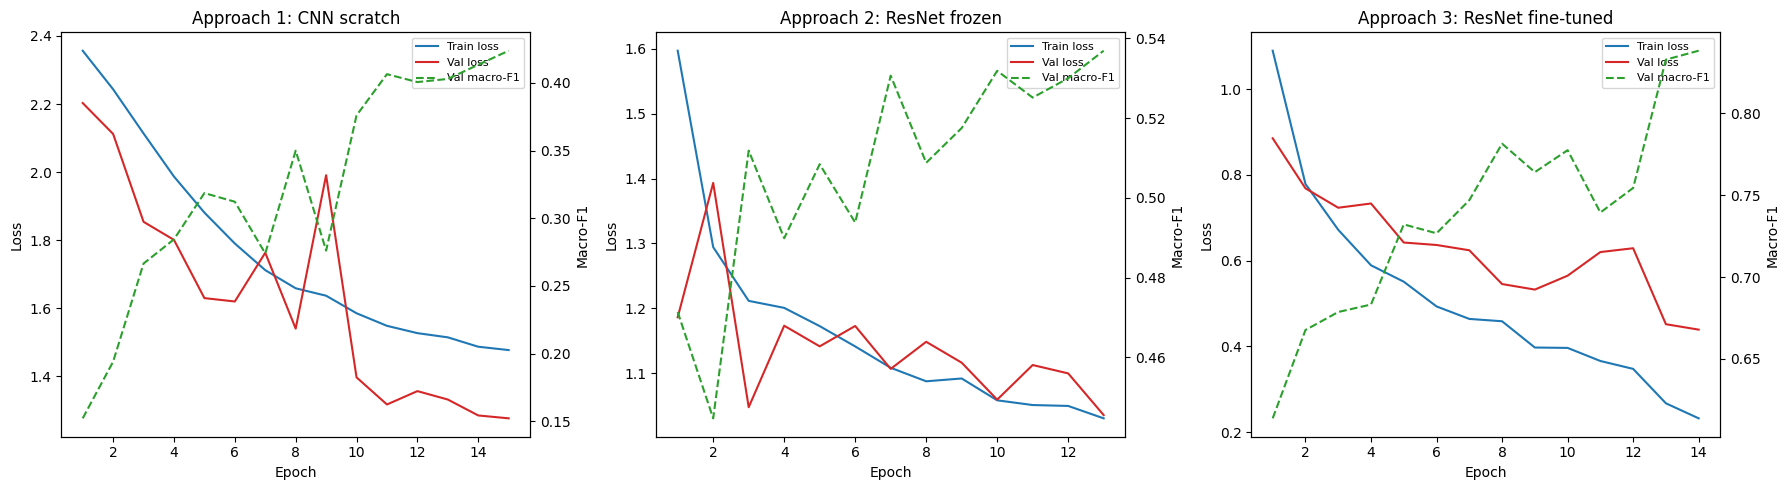

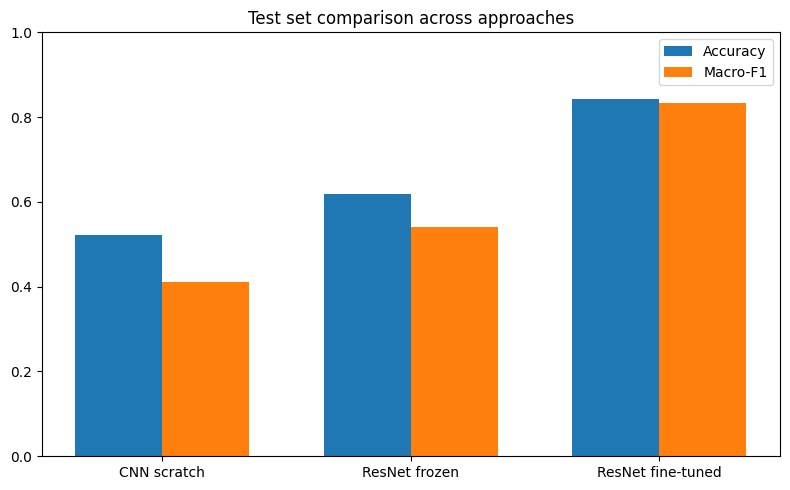

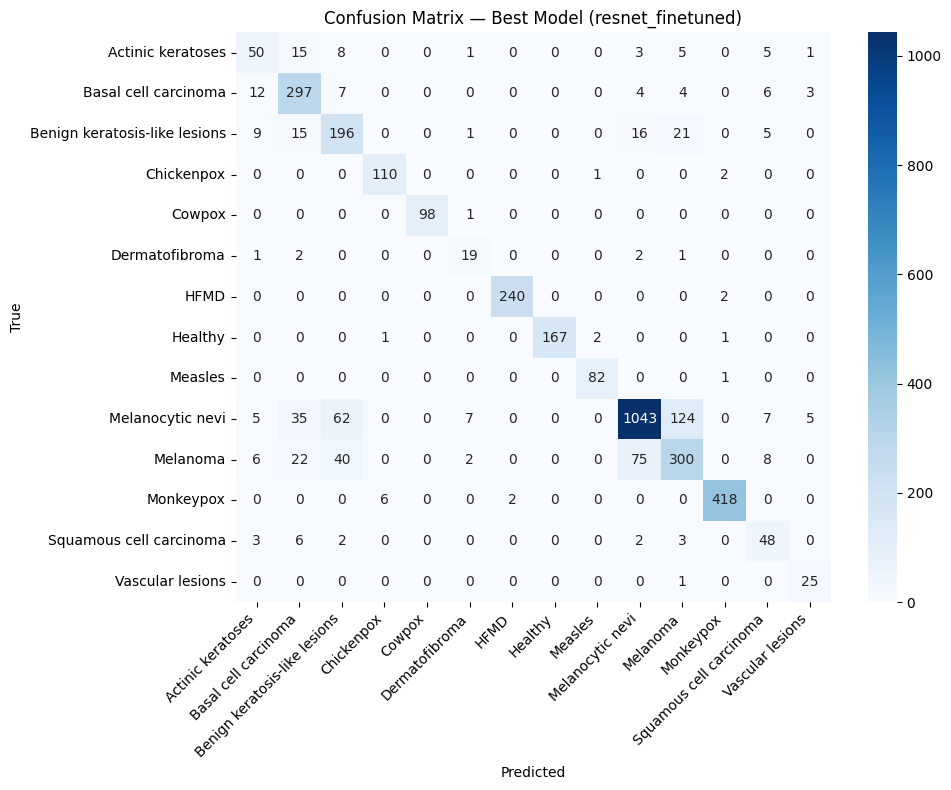

                               precision    recall  f1-score   support

            Actinic keratoses       0.58      0.57      0.57        88
         Basal cell carcinoma       0.76      0.89      0.82       333
Benign keratosis-like lesions       0.62      0.75      0.68       263
                   Chickenpox       0.94      0.97      0.96       113
                       Cowpox       1.00      0.99      0.99        99
               Dermatofibroma       0.61      0.76      0.68        25
                         HFMD       0.99      0.99      0.99       242
                      Healthy       1.00      0.98      0.99       171
                      Measles       0.96      0.99      0.98        83
             Melanocytic nevi       0.91      0.81      0.86      1288
                     Melanoma       0.65      0.66      0.66       453
                    Monkeypox       0.99      0.98      0.98       426
      Squamous cell carcinoma       0.61      0.75      0.67        64
     

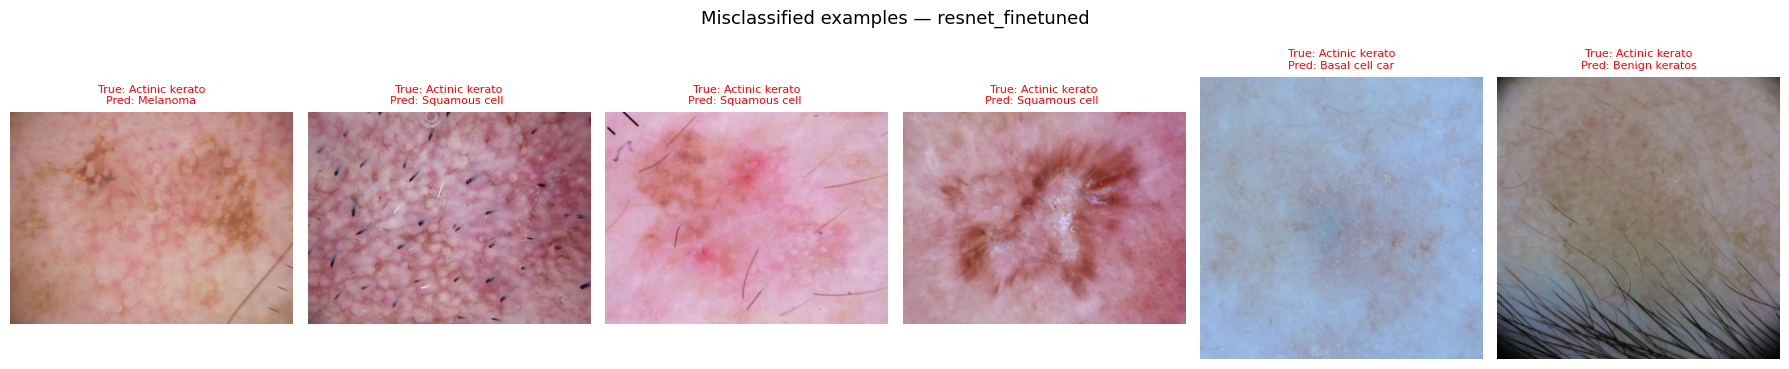


All done. Results saved under: /content/drive/MyDrive/Skin_Lesion_Project/results
Copy metrics.csv, figures/, hyperparameter_tuning.csv, and the classification report into your GitHub repo's results/ folder for the README and slides.


In [15]:
"""## 7. Final Evaluation, Comparison Figures & Error Analysis"""

# === Part 1: Recreate the EXACT CustomCNN architecture that was trained and saved ===
# (This MUST match the checkpoint exactly, which used conv1-conv4 and 128 features)
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2))
        self.conv2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.conv3 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.conv4 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

# === Part 2: Recover hist_1 / params_1 / time_1 from the saved checkpoint ===
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_ckpt = torch.load(os.path.join(CKPT_DIR, 'cnn_scratch_best.pth'), map_location=device)
hist_1 = cnn_ckpt['history']

temp_cnn = CustomCNN(NUM_CLASSES).to(device)
temp_cnn.load_state_dict(cnn_ckpt['model_state_dict'])
params_1 = count_trainable_params(temp_cnn)

# Note: Update this time if your actual training time was different
time_1 = 158.3 * 60

# === Part 3: Final evaluation, comparison table, and all figures ===
def build_and_load(arch_ctor, ckpt_name):
    model = arch_ctor().to(device)
    ckpt = torch.load(os.path.join(CKPT_DIR, f'{ckpt_name}_best.pth'), map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    return model

def evaluate_model(model, loader, name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = torch.argmax(model(imgs), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    print(f"{name}: acc={acc:.4f} macroF1={f1:.4f} precision={prec:.4f} recall={rec:.4f}")
    return acc, f1, prec, rec, all_labels, all_preds

def make_cnn():
    return CustomCNN(NUM_CLASSES)

def make_resnet():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

eval_model_1 = build_and_load(make_cnn, "cnn_scratch")
eval_model_2 = build_and_load(make_resnet, "resnet_frozen")
eval_model_3 = build_and_load(make_resnet, "resnet_finetuned")

res_1 = evaluate_model(eval_model_1, test_loader, "Approach 1 (CNN scratch)")
res_2 = evaluate_model(eval_model_2, test_loader, "Approach 2 (ResNet frozen)")
res_3 = evaluate_model(eval_model_3, test_loader, "Approach 3 (ResNet fine-tuned)")

# Pull params_2, time_2, params_3, time_3 from the checkpoints too
frozen_ckpt = torch.load(os.path.join(CKPT_DIR, 'resnet_frozen_best.pth'), map_location=device)
hist_2 = frozen_ckpt['history']
params_2 = count_trainable_params(eval_model_2)
time_2 = 98.0 * 60

finetuned_ckpt = torch.load(os.path.join(CKPT_DIR, 'resnet_finetuned_best.pth'), map_location=device)
hist_3 = finetuned_ckpt['history']
params_3 = count_trainable_params(eval_model_3)
time_3 = 99.9 * 60

results_df = pd.DataFrame({
    'Approach': ['1. CNN scratch', '2. ResNet-18 frozen', '3. ResNet-18 fine-tuned'],
    'Test Accuracy': [res_1[0], res_2[0], res_3[0]],
    'Test Macro-F1': [res_1[1], res_2[1], res_3[1]],
    'Test Macro-Precision': [res_1[2], res_2[2], res_3[2]],
    'Test Macro-Recall': [res_1[3], res_2[3], res_3[3]],
    'Trainable Params': [params_1, params_2, params_3],
    'Training Time (min)': [round(time_1/60, 1), round(time_2/60, 1), round(time_3/60, 1)],
    'Hardware': [hardware_name]*3,
})
results_df.to_csv(f'{RESULTS_DIR}/metrics.csv', index=False)
print("\nFinal results table:")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
histories = [hist_1, hist_2, hist_3]
titles = ["Approach 1: CNN scratch", "Approach 2: ResNet frozen", "Approach 3: ResNet fine-tuned"]
for ax, hist, title in zip(axes, histories, titles):
    ep = range(1, len(hist['train_loss']) + 1)
    ax.plot(ep, hist['train_loss'], label='Train loss', color='tab:blue')
    ax.plot(ep, hist['val_loss'], label='Val loss', color='tab:red')
    ax2 = ax.twinx()
    ax2.plot(ep, hist['val_f1'], label='Val macro-F1', color='tab:green', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax2.set_ylabel('Macro-F1')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/learning_curves.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, results_df['Test Accuracy'], width, label='Accuracy')
ax.bar(x + width/2, results_df['Test Macro-F1'], width, label='Macro-F1')
ax.set_xticks(x)
ax.set_xticklabels(['CNN scratch', 'ResNet frozen', 'ResNet fine-tuned'])
ax.set_ylim(0, 1)
ax.set_title('Test set comparison across approaches')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/approach_comparison.png', dpi=150)
plt.show()

best_idx = int(np.argmax(results_df['Test Macro-F1']))
best_name = ['cnn_scratch', 'resnet_frozen', 'resnet_finetuned'][best_idx]
best_labels, best_preds = [res_1, res_2, res_3][best_idx][4], [res_1, res_2, res_3][best_idx][5]

cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix — Best Model ({best_name})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/confusion_matrix.png', dpi=150)
plt.show()

report = classification_report(best_labels, best_preds, target_names=CLASSES, zero_division=0)
print(report)
with open(f'{RESULTS_DIR}/classification_report_{best_name}.txt', 'w') as f:
    f.write(report)

from PIL import Image
misclassified = [i for i, (p, t) in enumerate(zip(best_preds, best_labels)) if p != t]
num_to_show = min(6, len(misclassified))
if num_to_show > 0:
    fig, axes = plt.subplots(1, num_to_show, figsize=(3*num_to_show, 4))
    if num_to_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, misclassified[:num_to_show]):
        # test_ds is an ImageFolder, so .samples works perfectly here!
        img_path, _ = test_ds.samples[idx]
        true_label = IDX_TO_CLASS[best_labels[idx]]
        pred_label = IDX_TO_CLASS[best_preds[idx]]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"True: {true_label[:14]}\nPred: {pred_label[:14]}", fontsize=8, color='red')
        ax.axis('off')
    plt.suptitle(f'Misclassified examples — {best_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/misclassified_examples.png', dpi=150)
    plt.show()
else:
    print("No misclassified examples found on the test set.")

print(f"\nAll done. Results saved under: {RESULTS_DIR}")
print("Copy metrics.csv, figures/, hyperparameter_tuning.csv, and the classification report "
      "into your GitHub repo's results/ folder for the README and slides.")